# DrugReview R1 — ALBERT Multi-Task Aspect Model (Efficacy + Safety)

One shared **ALBERT** backbone with two 3-class aspect heads (`ai_efficacy`, `ai_safety`). One of **four parallel notebooks** = 2 cohorts x {without, with} metadata.

Conventions follow the canonical Manuscript 3 DrugReview pipeline (`NLP-LLM-Evaluation/Manuscript3/03_Hard_Label_Primary/DrugReview_Aspect_*`): GroupShuffleSplit (rs=42) on review text, **metadata textualized into `model_text`** for the DL model, balanced-weighted cross-entropy, AutoTokenizer, FP16 + OneCycleLR + grad-clip, and classification-report / bootstrap-CI / ROC evaluation.

## 1. Setup

In [ ]:
# @cell:pipinstall
# Colab usually ships torch + transformers. Uncomment if needed:
# !pip install -q transformers

In [ ]:
# @cell:imports
import os, re, gc, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_auc_score, roc_curve, auc, accuracy_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
try:
    from torch.amp import autocast, GradScaler
except Exception:
    from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AlbertModel

warnings.filterwarnings('ignore')

In [ ]:
# @cell:seed
SEED = 2025
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1.1 Configuration

In [ ]:
# @cell:config
# ============================================================
#  RUN CONFIGURATION  (only cell that differs across the 4 notebooks)
# ============================================================
COHORT       = "heterogeneous"          # mood_anxiety | heterogeneous
USE_METADATA = True      # False = review only | True = metadata textualized into model_text
RUN_ID       = "T54_heterogeneous_with_metadata"
CSV_NAME     = "drugsCom_generalized_with_ai_labels_mini.csv"

# ---- Aspect heads: joint efficacy + safety, 3-class each ----
ASPECT_NAMES       = ["ai_efficacy", "ai_safety"]
ASPECT_CLASSES     = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_ASPECT_CLASSES = len(ASPECT_CLASSES)
ASPECT_LABEL_MAP   = {v: i for i, v in enumerate(ASPECT_CLASSES)}

TEXT_COLUMN0 = "review"       # raw review column
ALBERT_MODEL_NAME = "albert-base-v2"

# ---- Training (Manuscript 3 canonical) ----
MAX_TOKEN_LENGTH = 200
BATCH_SIZE       = 128
N_ITERATIONS     = 10
PATIENCE         = 3
RANDOM_STATE     = 42          # GroupShuffleSplit seed
MAX_GRAD_NORM    = 1.0
RETRAIN          = True

USE_FP16       = torch.cuda.is_available()
TORCH_COMPILE_OK = hasattr(torch, "compile")

# ---- Paths: one experiment folder holds data/ and outputs/ ----
EXPERIMENT_ROOT = Path("/content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R1/T54_heterogeneous_with_metadata")
DATA_PATH   = EXPERIMENT_ROOT / "data" / CSV_NAME
OUTPUT_PATH = EXPERIMENT_ROOT / "outputs"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

def resolve_data_path():      # path is fixed; kept so the load cell runs unchanged
    return DATA_PATH

print("COHORT       =", COHORT)
print("USE_METADATA =", USE_METADATA)
print("ASPECTS      =", ASPECT_NAMES)
print("DATA_PATH    =", DATA_PATH)
print("OUTPUT_PATH  =", OUTPUT_PATH)


COHORT       = heterogeneous
USE_METADATA = True
ASPECTS      = ['ai_efficacy', 'ai_safety']
DATA_PATH    = /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R1/T54_heterogeneous_with_metadata/data/drugsCom_generalized_with_ai_labels_mini.csv
OUTPUT_PATH  = /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R1/T54_heterogeneous_with_metadata/outputs


## 1.2 Mount Drive & load data

In [ ]:
# @cell:mount
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [ ]:
# @cell:load
DATA_PATH = resolve_data_path()
df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df_raw):,} rows from {DATA_PATH}')
df_raw.head()

Loaded 28,755 rows from /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R1/T54_heterogeneous_with_metadata/data/drugsCom_generalized_with_ai_labels_mini.csv


,uniqueID,drugName,condition,review,rating,date,usefulCount,condition_clean,sentiment_5,ai_rating_10,ai_sentiment_5,ai_efficacy,ai_safety,ai_raw_json_mini,ai_prob_very_negative,ai_prob_negative,ai_prob_neutral,ai_prob_positive,ai_prob_very_positive
0,198878,Depo-Provera,Abnormal Uterine Bleeding,"""Had my daughter in September. I bled for 4 we...",1,5-Nov-16,12,Abnormal Uterine Bleeding,very_negative,1.0,VERY_NEGATIVE,NEGATIVE,NEGATIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.6,0.3,0.1,0.0,0.0
1,167406,Levonorgestrel,Abnormal Uterine Bleeding,"""I am a 45, &amp; never pregnant (my husband o...",2,14-Mar-16,24,Abnormal Uterine Bleeding,very_negative,2.0,VERY_NEGATIVE,NEGATIVE,NEGATIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.5,0.4,0.1,0.0,0.0
2,13998,Megestrol,Abnormal Uterine Bleeding,"""About two weeks ago I had to be hospitalized ...",10,22-Mar-17,8,Abnormal Uterine Bleeding,very_positive,8.0,POSITIVE,POSITIVE,POSITIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.0,0.1,0.4,0.5
3,198705,Depo-Provera,Abnormal Uterine Bleeding,"""I started my first Depo shot in July of 2016 ...",1,31-Jan-17,2,Abnormal Uterine Bleeding,very_negative,1.0,VERY_NEGATIVE,NEGATIVE,NEGATIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.7,0.2,0.1,0.0,0.0
4,44046,Ethinyl estradiol / norgestimate,Abnormal Uterine Bleeding,"""I&#039;ve been taking Tri-Sprintec for almost...",8,10-Jan-12,3,Abnormal Uterine Bleeding,positive,6.0,NEUTRAL,POSITIVE,NEUTRAL,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.2,0.2,0.4,0.2


## 2. Build model text (metadata textualized for the DL model) & clean

In [ ]:
# @cell:modeltext
def normalize_meta(series):
    return (series.fillna('').astype(str).str.strip().str.lower()
            .str.replace(r'\s+', ' ', regex=True))

df = df_raw.copy()
df['drug_norm'] = normalize_meta(df['drugName']) if 'drugName' in df.columns else ''
if 'condition_clean' in df.columns:
    _cond = df['condition_clean'].where(df['condition_clean'].notna(), df.get('condition'))
else:
    _cond = df.get('condition')
df['condition_norm'] = normalize_meta(_cond) if _cond is not None else ''
df['useful_num'] = pd.to_numeric(df.get('usefulCount'), errors='coerce').fillna(0).astype(int)

# DL convention (Manuscript 3): textualize metadata into the input for the 'with metadata' runs;
# text-only runs feed the raw review. Field markers ([DRUG]/[COND]/[USEFUL]/[TEXT]) become
# plain marker words after clean_text strips brackets.
def build_model_text(r):
    return (f"[DRUG] {r['drug_norm']} [COND] {r['condition_norm']} "
            f"[USEFUL] {r['useful_num']} [TEXT] {r[TEXT_COLUMN0]}")

if USE_METADATA:
    df['model_text'] = df.apply(build_model_text, axis=1)
else:
    df['model_text'] = df[TEXT_COLUMN0].fillna('').astype(str)
print('Example model_text:\n', df['model_text'].iloc[0][:200])

Example model_text:
 [DRUG] depo-provera [COND] abnormal uterine bleeding [USEFUL] 12 [TEXT] "Had my daughter in September. I bled for 4 weeks after my delivery. At my PP visit my doctor suggested the depo shot. She menti


In [ ]:
# @cell:clean
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+', ' urltoken ', text)
    text = re.sub(r'@\w+', ' usertoken ', text)
    text = re.sub(r'#(\w+)', r' hashtag_\1 ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_clean'] = df['model_text'].apply(clean_text)
# review-level group key (never let the same review span splits)
df['group_key'] = (df[TEXT_COLUMN0].fillna('').astype(str).str.lower()
                   .str.replace(r'\s+', ' ', regex=True).str.strip())
print('Cleaned', len(df), 'rows')

Cleaned 28755 rows


In [ ]:
# @cell:labels
print('Aspect label distributions:')
for asp in ASPECT_NAMES:
    if asp not in df.columns:
        raise ValueError(f'Missing aspect column: {asp}')
    df[asp] = df[asp].astype(str).str.upper().str.strip()
    df[asp] = df[asp].replace({'VERY_POSITIVE': 'POSITIVE', 'VERY_NEGATIVE': 'NEGATIVE'})
    bad = ~df[asp].isin(ASPECT_CLASSES)
    if bad.any():
        print(f'  {asp}: {int(bad.sum())} invalid -> NEUTRAL')
        df.loc[bad, asp] = 'NEUTRAL'
    df[f'{asp}_idx'] = df[asp].map(ASPECT_LABEL_MAP).astype(np.int64)
    print(f'  {asp}: {df[asp].value_counts().to_dict()}')

Aspect label distributions:
  ai_efficacy: {'POSITIVE': 16640, 'NEGATIVE': 9267, 'NEUTRAL': 2848}
  ai_safety: {'NEGATIVE': 12080, 'NEUTRAL': 9288, 'POSITIVE': 7387}


## 2.1 Group split (60 / 20 / 20, rs=42) — no review leaks across splits

In [ ]:
# @cell:split
groups  = df['group_key'].to_numpy()
y_strat = df[f'{ASPECT_NAMES[0]}_idx'].to_numpy()

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss1.split(df, y_strat, groups=groups))
split = np.array(['train'] * len(df), dtype=object)
split[test_idx] = 'test'

df_tv = df.iloc[trainval_idx].reset_index(drop=True)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
_tr, _va = next(gss2.split(df_tv, df_tv[f'{ASPECT_NAMES[0]}_idx'], groups=df_tv['group_key']))
split[trainval_idx[_va]] = 'val'
df['split'] = split

print('Split counts:'); print(df['split'].value_counts())
n_leak = int((df.groupby('group_key')['split'].nunique() > 1).sum())
assert n_leak == 0, f'{n_leak} review groups leak across splits!'
print('Group-split leakage check passed (0 reviews span splits).')

Split counts:
split
train    17289
val       5752
test      5714
Name: count, dtype: int64
Group-split leakage check passed (0 reviews span splits).


In [ ]:
# @cell:splitframes
df_train = df[df.split == 'train'].reset_index(drop=True)
df_val   = df[df.split == 'val'].reset_index(drop=True)
df_test  = df[df.split == 'test'].reset_index(drop=True)

train_texts = df_train['text_clean'].tolist()
val_texts   = df_val['text_clean'].tolist()
test_texts  = df_test['text_clean'].tolist()

y_train = {a: df_train[f'{a}_idx'].to_numpy() for a in ASPECT_NAMES}
y_val   = {a: df_val[f'{a}_idx'].to_numpy()   for a in ASPECT_NAMES}
y_test  = {a: df_test[f'{a}_idx'].to_numpy()  for a in ASPECT_NAMES}

# Balanced class weights per aspect (Manuscript 3 DL convention)
aspect_weights = {}
for a in ASPECT_NAMES:
    uniq = np.unique(y_train[a])
    w = compute_class_weight('balanced', classes=uniq, y=y_train[a])
    full = np.ones(NUM_ASPECT_CLASSES, dtype=np.float32)
    for cid, wi in zip(uniq, w):
        full[cid] = wi
    aspect_weights[a] = torch.tensor(full, dtype=torch.float32).to(DEVICE)
    print(a, 'class weights:', full.round(3))
print('Train/Val/Test:', len(df_train), len(df_val), len(df_test))

ai_efficacy class weights: [1.03  3.366 0.577]
ai_safety class weights: [0.792 1.034 1.299]
Train/Val/Test: 17289 5752 5714


## 3. Tokenize, dataset & ALBERT multi-task model

In [ ]:
# @cell:dataset
tokenizer = AutoTokenizer.from_pretrained(ALBERT_MODEL_NAME)

def batch_tokenize(texts, max_len=MAX_TOKEN_LENGTH, chunk=512):
    ids, masks = [], []
    for i in range(0, len(texts), chunk):
        enc = tokenizer([str(t) for t in texts[i:i+chunk]], max_length=max_len,
                        truncation=True, padding='max_length', return_tensors='pt')
        ids.append(enc['input_ids']); masks.append(enc['attention_mask'])
    return torch.cat(ids), torch.cat(masks)

class AspectDataset(Dataset):
    def __init__(self, input_ids, masks, labels):
        self.input_ids = input_ids; self.masks = masks
        self.labels = {a: torch.tensor(np.asarray(v, dtype=np.int64)) for a, v in labels.items()}
    def __len__(self):
        return self.input_ids.shape[0]
    def __getitem__(self, i):
        item = {'input_ids': self.input_ids[i], 'attention_mask': self.masks[i]}
        for a in ASPECT_NAMES:
            item[f'{a}_label'] = self.labels[a][i]
        return item

print('Tokenizing...')
tr_ids, tr_m = batch_tokenize(train_texts)
va_ids, va_m = batch_tokenize(val_texts)
te_ids, te_m = batch_tokenize(test_texts)

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
train_loader = DataLoader(AspectDataset(tr_ids, tr_m, y_train), shuffle=True,  **loader_kw)
val_loader   = DataLoader(AspectDataset(va_ids, va_m, y_val),   shuffle=False, **loader_kw)
test_loader  = DataLoader(AspectDataset(te_ids, te_m, y_test),  shuffle=False, **loader_kw)
print('Loaders ready.')

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Tokenizing...
Loaders ready.


In [ ]:
# @cell:model
class AspectALBERT(nn.Module):
    """Shared ALBERT backbone ([CLS]) + one 3-class head per aspect."""
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.base = AlbertModel.from_pretrained(model_name)
        hidden = self.base.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({a: nn.Linear(hidden, NUM_ASPECT_CLASSES) for a in ASPECT_NAMES})
    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return {a: head(cls) for a, head in self.heads.items()}

## 4. Training (FP16 + OneCycleLR + grad-clip; random search)

In [ ]:
# @cell:train
def train_albert(model, train_loader, val_loader, lr=2e-5, max_epochs=6, patience=PATIENCE):
    model.to(DEVICE)
    if TORCH_COMPILE_OK:
        try:
            model = torch.compile(model, mode='reduce-overhead')
        except Exception:
            pass
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * max(1, len(train_loader))
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criteria = {a: nn.CrossEntropyLoss(weight=aspect_weights[a]) for a in ASPECT_NAMES}
    scaler = GradScaler(enabled=USE_FP16)
    best_f1, best_state, best_ep, stale = -1.0, None, -1, 0
    for epoch in range(1, max_epochs + 1):
        model.train(); losses = []
        for batch in train_loader:
            ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=USE_FP16):
                logits = model(ids, mask)
                loss = sum(criteria[a](logits[a], batch[f'{a}_label'].to(DEVICE)) for a in ASPECT_NAMES)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            losses.append(loss.item())
        model.eval(); vt = {a: [] for a in ASPECT_NAMES}; vp = {a: [] for a in ASPECT_NAMES}
        with torch.no_grad():
            for batch in val_loader:
                ids = batch['input_ids'].to(DEVICE, non_blocking=True)
                mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
                with autocast('cuda', enabled=USE_FP16):
                    logits = model(ids, mask)
                for a in ASPECT_NAMES:
                    vp[a].extend(logits[a].float().argmax(1).cpu().numpy())
                    vt[a].extend(batch[f'{a}_label'].numpy())
        f1s = {a: f1_score(vt[a], vp[a], average='weighted') for a in ASPECT_NAMES}
        mean_f1 = float(np.mean(list(f1s.values())))
        print(f'  epoch {epoch}/{max_epochs} loss={np.mean(losses):.4f} meanF1={mean_f1:.4f} ' +
              ' '.join(f"{a.replace('ai_','')}={f1s[a]:.3f}" for a in ASPECT_NAMES))
        raw = model._orig_mod if hasattr(model, '_orig_mod') else model
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            best_ep = epoch; stale = 0
        else:
            stale += 1
            if stale >= patience:
                print('  early stop'); break
    raw = model._orig_mod if hasattr(model, '_orig_mod') else model
    if best_state is not None:
        raw.load_state_dict(best_state)
    return best_f1, raw, best_ep

In [ ]:
# @cell:search
MODEL_PATH  = OUTPUT_PATH / 'best_albert_aspect.pth'
PARAMS_PATH = OUTPUT_PATH / 'best_albert_aspect_params.json'

if RETRAIN:
    set_seed(); start = time.time()
    space = {'lr': (np.log10(1e-5), np.log10(3e-5)), 'epochs': (4, 10), 'dropout': (0.0, 0.25)}
    best_f1, best_params, best_model = 0.0, None, None
    for it in tqdm(range(N_ITERATIONS), desc=f'ALBERT search [{RUN_ID}]'):
        hp = {'lr': float(10 ** np.random.uniform(*space['lr'])),
              'epochs': int(np.random.randint(*space['epochs'])),
              'dropout': float(np.random.uniform(*space['dropout']))}
        model = AspectALBERT(ALBERT_MODEL_NAME, dropout=hp['dropout'])
        f1v, model, ep = train_albert(model, train_loader, val_loader,
                                      lr=hp['lr'], max_epochs=hp['epochs'])
        if f1v > best_f1:
            best_f1, best_params, best_model = f1v, {**hp, 'best_epoch': ep}, model
            torch.save(model.state_dict(), MODEL_PATH)
        del model; gc.collect(); torch.cuda.empty_cache()
    json.dump(best_params, open(PARAMS_PATH, 'w'), indent=2)
    print(f'Best val mean-F1 = {best_f1:.4f} | params = {best_params} | {time.time()-start:.0f}s')
else:
    best_params = json.load(open(PARAMS_PATH))
    best_model = AspectALBERT(ALBERT_MODEL_NAME, dropout=best_params.get('dropout', 0.1))
    best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE).eval()
print('Best model ready.')

ALBERT search [T54_heterogeneous_with_metadata]:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.bias             | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/6 loss=1.9111 meanF1=0.7184 efficacy=0.769 safety=0.668
  epoch 2/6 loss=1.2774 meanF1=0.7503 efficacy=0.793 safety=0.708
  epoch 3/6 loss=1.0526 meanF1=0.7761 efficacy=0.822 safety=0.730
  epoch 4/6 loss=0.8709 meanF1=0.7814 efficacy=0.825 safety=0.738
  epoch 5/6 loss=0.7335 meanF1=0.7833 efficacy=0.831 safety=0.736
  epoch 6/6 loss=0.6585 meanF1=0.7808 efficacy=0.827 safety=0.735


...

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.bias             | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/6 loss=1.8514 meanF1=0.7346 efficacy=0.787 safety=0.682
  epoch 2/6 loss=1.2433 meanF1=0.7527 efficacy=0.788 safety=0.717
  epoch 3/6 loss=0.9972 meanF1=0.7713 efficacy=0.812 safety=0.730
  epoch 4/6 loss=0.7995 meanF1=0.7837 efficacy=0.827 safety=0.741
  epoch 5/6 loss=0.6348 meanF1=0.7934 efficacy=0.842 safety=0.745
  epoch 6/6 loss=0.5425 meanF1=0.7922 efficacy=0.840 safety=0.744


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.bias             | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/9 loss=1.9075 meanF1=0.7175 efficacy=0.753 safety=0.682
  epoch 2/9 loss=1.2508 meanF1=0.7488 efficacy=0.762 safety=0.735
  epoch 3/9 loss=1.0187 meanF1=0.7669 efficacy=0.794 safety=0.740
  epoch 4/9 loss=0.8114 meanF1=0.7952 efficacy=0.839 safety=0.751
  epoch 5/9 loss=0.6139 meanF1=0.7835 efficacy=0.829 safety=0.738
  epoch 6/9 loss=0.4216 meanF1=0.7926 efficacy=0.835 safety=0.750
  epoch 7/9 loss=0.2707 meanF1=0.7922 efficacy=0.837 safety=0.747
  early stop
Best val mean-F1 = 0.7952 | params = {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'best_epoch': 4} | 1865s
Best model ready.


## 5. Evaluation (per aspect: report, bootstrap F1 CI, confusion, ROC, macro AUC)

ai_efficacy   (3-class: NEGATIVE / NEUTRAL / POSITIVE)
              precision    recall  f1-score   support

    NEGATIVE     0.8530    0.8549    0.8540      1840
     NEUTRAL     0.4298    0.5445    0.4804       573
    POSITIVE     0.9141    0.8706    0.8919      3301

    accuracy                         0.8329      5714
   macro avg     0.7323    0.7567    0.7421      5714
weighted avg     0.8459    0.8329    0.8384      5714

Accuracy       : 0.8329
Macro F1       : 0.7421
Weighted F1    : 0.8386  95% CI [0.8292, 0.8481]
Macro AUC (OvR): 0.9319  95% CI [0.9257, 0.9380]


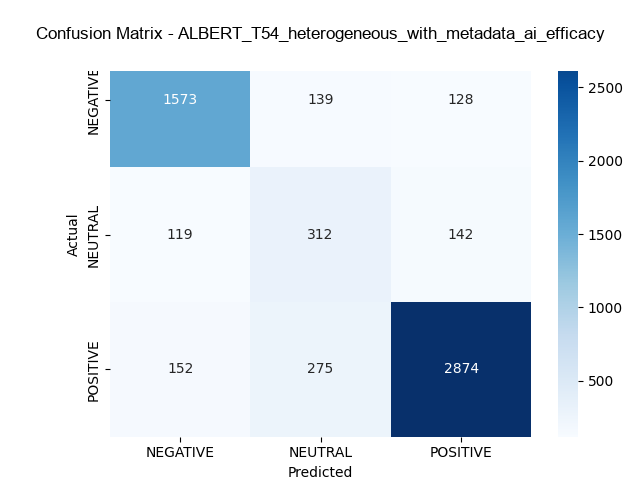

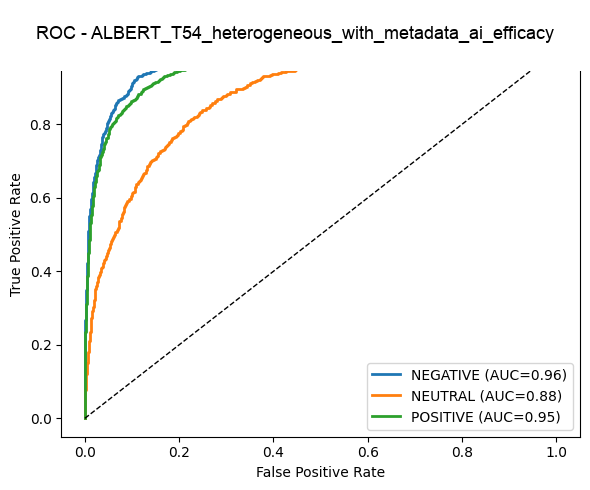

ai_safety   (3-class: NEGATIVE / NEUTRAL / POSITIVE)
              precision    recall  f1-score   support

    NEGATIVE     0.8660    0.7975    0.8303      2390
     NEUTRAL     0.6136    0.7112    0.6588      1849
    POSITIVE     0.7620    0.7078    0.7339      1475

    accuracy                         0.7464      5714
   macro avg     0.7472    0.7388    0.7410      5714
weighted avg     0.7575    0.7464    0.7499      5714

Accuracy       : 0.7464
Macro F1       : 0.7410
Weighted F1    : 0.7498  95% CI [0.7391, 0.7607]
Macro AUC (OvR): 0.9037  95% CI [0.8975, 0.9096]


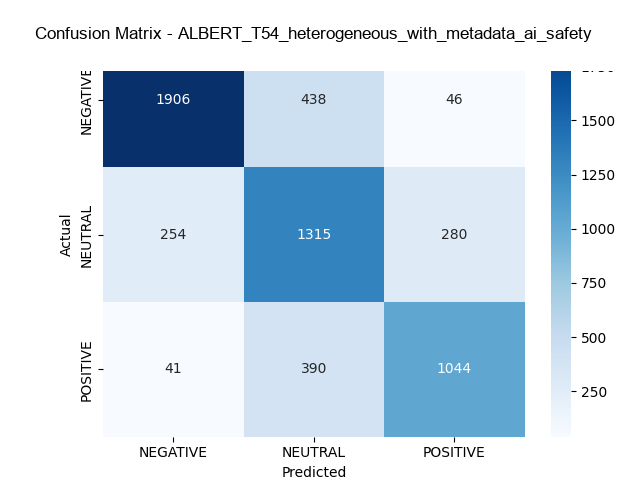

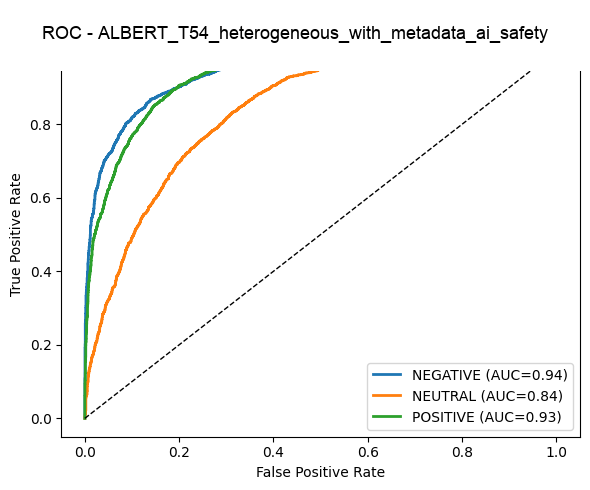

In [ ]:
# @cell:eval
def bootstrap_f1_ci(y_true, y_pred, n=1000, average='weighted'):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); s = []
    for _ in range(n):
        idx = resample(np.arange(len(y_true)))
        try:
            s.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    return (float(np.mean(s)), float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))) if s else (np.nan,)*3

def bootstrap_auc_ci(y_true, y_prob, n=1000):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob); s = []
    for _ in range(n):
        idx = resample(np.arange(len(y_true)))
        try:
            s.append(roc_auc_score(y_true[idx], y_prob[idx], average='macro', multi_class='ovr'))
        except ValueError:
            continue
    return (float(np.mean(s)), float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))) if s else (np.nan,)*3

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_ASPECT_CLASSES)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ASPECT_CLASSES, yticklabels=ASPECT_CLASSES)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix - {title}')
    plt.tight_layout(); plt.savefig(OUTPUT_PATH / f'{title}_confusion_matrix.png', dpi=200); plt.show()

def plot_multiclass_roc(y_true, y_prob, title):
    y_bin = label_binarize(y_true, classes=list(range(NUM_ASPECT_CLASSES)))
    plt.figure(figsize=(6, 5))
    for i, name in enumerate(ASPECT_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC - {title}'); plt.legend(loc='lower right')
    plt.tight_layout(); plt.savefig(OUTPUT_PATH / f'{title}_roc_curve.png', dpi=200); plt.show()

best_model.eval()
logits_all = {a: [] for a in ASPECT_NAMES}; true_all = {a: [] for a in ASPECT_NAMES}
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        with autocast('cuda', enabled=USE_FP16):
            logits = best_model(ids, mask)
        for a in ASPECT_NAMES:
            logits_all[a].append(logits[a].float().cpu().numpy())
            true_all[a].extend(batch[f'{a}_label'].numpy())

results = {}
for a in ASPECT_NAMES:
    lg = np.concatenate(logits_all[a])
    prob = torch.softmax(torch.tensor(lg), dim=1).numpy()
    pred = prob.argmax(1); true = np.asarray(true_all[a])
    print('=' * 58); print(f'{a}   (3-class: NEGATIVE / NEUTRAL / POSITIVE)'); print('=' * 58)
    print(classification_report(true, pred, labels=list(range(NUM_ASPECT_CLASSES)),
                                target_names=ASPECT_CLASSES, digits=4, zero_division=0))
    f1m, f1lo, f1hi = bootstrap_f1_ci(true, pred)
    aucm, auclo, auchi = bootstrap_auc_ci(true, prob)
    print(f'Accuracy       : {accuracy_score(true, pred):.4f}')
    print(f'Macro F1       : {f1_score(true, pred, average="macro", zero_division=0):.4f}')
    print(f'Weighted F1    : {f1m:.4f}  95% CI [{f1lo:.4f}, {f1hi:.4f}]')
    print(f'Macro AUC (OvR): {aucm:.4f}  95% CI [{auclo:.4f}, {auchi:.4f}]')
    plot_confusion_matrix(true, pred, f'ALBERT_{RUN_ID}_{a}')
    plot_multiclass_roc(true, prob, f'ALBERT_{RUN_ID}_{a}')
    results[a] = {'y_true': true, 'y_pred': pred,
                  'accuracy': float(accuracy_score(true, pred)),
                  'macro_f1': float(f1_score(true, pred, average='macro', zero_division=0)),
                  'weighted_f1': f1m, 'f1_ci': (f1lo, f1hi),
                  'macro_auc': aucm, 'auc_ci': (auclo, auchi)}

## 6. Save predictions & summary

In [ ]:
# @cell:save
cols = [c for c in [TEXT_COLUMN0, 'drugName', 'condition', 'usefulCount'] if c in df_test.columns]
out = df_test[cols].copy()
for a in ASPECT_NAMES:
    out[f'{a}_true'] = results[a]['y_true']
    out[f'{a}_pred'] = results[a]['y_pred']
joint = np.ones(len(df_test), dtype=bool)
for a in ASPECT_NAMES:
    joint &= (results[a]['y_true'] == results[a]['y_pred'])
out['joint_correct'] = joint.astype(int)
pred_path = OUTPUT_PATH / 'test_predictions.csv'
out.to_csv(pred_path, index=False)

summary = {
    'run_id': RUN_ID, 'cohort': COHORT, 'use_metadata': bool(USE_METADATA),
    'data_file': CSV_NAME, 'data_path': str(DATA_PATH),
    'n_train': int(len(df_train)), 'n_val': int(len(df_val)), 'n_test': int(len(df_test)),
    'aspects': {a: {'accuracy': results[a]['accuracy'], 'macro_f1': results[a]['macro_f1'],
                    'weighted_f1': results[a]['weighted_f1'],
                    'f1_ci': [results[a]['f1_ci'][0], results[a]['f1_ci'][1]],
                    'macro_auc': results[a]['macro_auc'],
                    'auc_ci': [results[a]['auc_ci'][0], results[a]['auc_ci'][1]]}
                for a in ASPECT_NAMES},
    'joint_exact_match': float(joint.mean()),
}
json.dump(summary, open(OUTPUT_PATH / 'summary.json', 'w'), indent=2)
print(json.dumps(summary, indent=2))
print('Saved predictions ->', pred_path)

{
  "run_id": "T54_heterogeneous_with_metadata",
  "cohort": "heterogeneous",
  "use_metadata": true,
  "data_file": "drugsCom_generalized_with_ai_labels_mini.csv",
  "data_path": "/content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R1/T54_heterogeneous_with_metadata/data/drugsCom_generalized_with_ai_labels_mini.csv",
  "n_train": 17289,
  "n_val": 5752,
  "n_test": 5714,
  "aspects": {
    "ai_efficacy": {
      "accuracy": 0.8328666433321666,
      "macro_f1": 0.7420622497068639,
      "weighted_f1": 0.8385510474872995,
      "f1_ci": [
        0.8291534494855384,
        0.8480663327735728
      ],
      "macro_auc": 0.9318813996173767,
      "auc_ci": [
        0.925731924639911,
        0.9380219127851358
      ]
    },
    "ai_safety": {
      "accuracy": 0.7464123206160308,
      "macro_f1": 0.7410189944548922,
      "weighted_f1": 0.749847480126196,
      "f1_ci": [
        0.7390779868205147,
        0.7606913349559609
      ],
      "macro_auc": 0.9037293262437969,
      